# Block 1: Hierarchical Pooling for Bayesian MARCEL (wRC+)

Fits the Block 1 model: latent true-talent wRC+ per player-season with partial pooling toward a league-wide population distribution.

In [ ]:
import sys
sys.path.insert(0, '../../../src')

import importlib
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import models.marcel
importlib.reload(models.marcel)

from models.marcel import (
    load_and_filter,
    run_sanity_checks,
    build_block1_model,
    fit_block1,
    run_diagnostics,
)

## 1. Load and validate data

In [ ]:
df = load_and_filter('../../../data/fg_builds/fg_hitters_train.csv')
run_sanity_checks(df)
df.head(10)

In [ ]:
# Quick summary of the filtered dataset
print(f"Rows: {len(df)}, Unique players: {df['IDfg'].nunique()}")
print(f"Seasons: {sorted(df['Season'].unique())}")
print(f"\nPA distribution:")
print(df['PA'].describe())
print(f"\nwRC+ distribution:")
print(df['wRC+'].describe())

## 2. Build model

In [ ]:
model = build_block1_model(df)
model

In [ ]:
# Visualise the model graph (requires graphviz; skip if not installed)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print(f"Skipping model graph (graphviz not installed): {e}")

## 3. Sample posterior

Settings: 4 chains, 3000 tune, 2000 draws, target_accept=0.99.

In [ ]:
trace = fit_block1(model, target_accept=0.99, tune=3000, draws=2000)

## 4. Diagnostics

In [ ]:
# output_dir='.' saves plots in the same directory as this notebook
results = run_diagnostics(trace, df, output_dir='.')

## 5. Save trace

In [ ]:
import pickle

with open('block1_trace.pkl', 'wb') as f:
    pickle.dump(trace, f)
print('Trace saved to notebooks/models/block1_trace.pkl')

## 6. Inspect a single player-season

Fill in `player_name` and `season` below to see the posterior predictive distribution of wRC+ for that player-season.

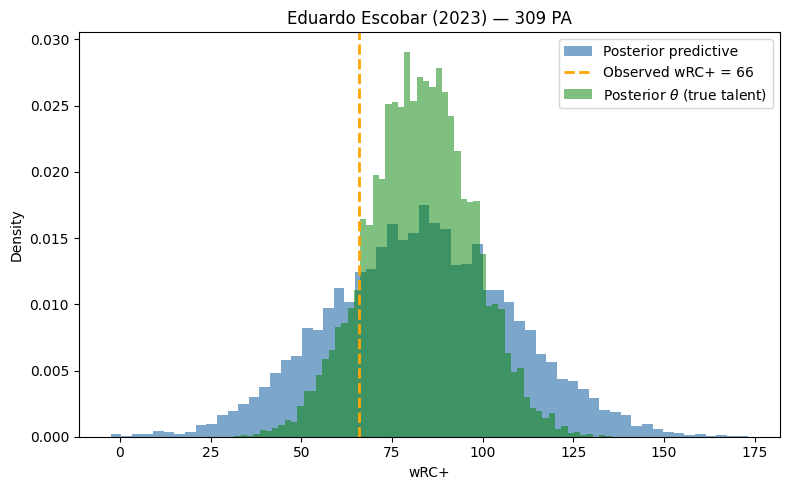

In [33]:
# ---- Fill these in ----
player_name = "Eduardo Escobar"
season      = 2023        # must be in 2016–2023
# ------------------------

# Look up player by name
matches = df[df["Name"] == player_name]
if matches.empty:
    raise ValueError(f"No player named '{player_name}' found in data")
unique_ids = matches["IDfg"].unique()
if len(unique_ids) > 1:
    raise ValueError(
        f"'{player_name}' maps to multiple player IDs: {unique_ids.tolist()}. "
        "Use IDfg directly to disambiguate."
    )

row = matches[matches["Season"] == season]
if row.empty:
    available = sorted(matches["Season"].unique())
    raise ValueError(f"'{player_name}' has no data for {season}. Available seasons: {available}")

player_id = row["IDfg"].values[0]
key = f"{player_id}_{season}"
obs_wrc = row["wRC+"].values[0]
obs_pa = row["PA"].values[0]

# Extract 4,000 posterior predictive draws for this player-season
ppc_draws = trace.posterior_predictive["wrc_plus"].sel(player_season=key).values.flatten()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ppc_draws, bins=60, density=True, alpha=0.7, color="steelblue", label="Posterior predictive")
ax.axvline(obs_wrc, color="orange", linewidth=2, linestyle="--", label=f"Observed wRC+ = {obs_wrc:.0f}")

# Also show the latent theta posterior for comparison
theta_draws = trace.posterior["theta"].sel(player_season=key).values.flatten()
ax.hist(theta_draws, bins=60, density=True, alpha=0.5, color="green", label=r"Posterior $\theta$ (true talent)")

ax.set_xlabel("wRC+")
ax.set_ylabel("Density")
ax.set_title(f"{player_name} ({season}) — {obs_pa} PA")
ax.legend()
plt.tight_layout()
plt.show()